In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)

In [2]:
num_episodes = 5000
alpha = 0.1 # agent updates slowly, giving 10% weight to new experience and keeping 90% of old knowledge.
gamma = 0.9
epsilon = 0.5 # agent explores 50% of the time and exploits 50% of the time.

reward_fire = -20
reward_goal = 100
reward_step = -1

actions = [(0,-1),(0,1),(-1,0),(1,0)]

Q = {}


In [3]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]: return False
    if c < 0 or c >= maze.shape[1]: return False
    if maze[r, c] == 1: return False
    return True

def choose_action(state):
    # FIX 2: If state not in Q, initialize it
    if state not in Q:
        Q[state] = [0, 0, 0, 0]

    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])


In [4]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    # FIX 3: Initialize Q for start state
    if state not in Q:
        Q[state] = [0, 0, 0, 0]

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        # Current state: (2, 3)
        # Chosen action: (1, 0) → move down
        # next_state = (2 + 1, 3 + 0)  # (3, 3)
        next_state = (state[0] + action[0], state[1] + action[1]) 

        # FIX 4: Initialize Q for next state
        if next_state not in Q:
            Q[next_state] = [0, 0, 0, 0]

        if not is_valid(next_state):
            reward = reward_fire
            done = True
            next_max = 0
        elif next_state == goal:
            reward = reward_goal
            done = True
            next_max = 0
        else:
            reward = reward_step
            next_max = max(Q[next_state])

        old_value = Q[state][action_index]

        Q[state][action_index] = old_value + alpha * (reward + gamma * next_max - old_value)

        if is_valid(next_state):
            state = next_state

        total_rewards += reward

    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)

print("Training finished.")

Training finished.


In [5]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=300):
    path = [start]
    state = start

    for _ in range(max_steps):
        if state == goal:
            break

        # Make sure state exists in Q
        if state not in Q:
            break

        # Choose best action from dictionary Q
        action_index = np.argmax(Q[state])
        dr, dc = actions[action_index]

        next_state = (state[0] + dr, state[1] + dc)

        # Stop if invalid
        if not is_valid(next_state):
            break

        path.append(next_state)
        state = next_state

    return path


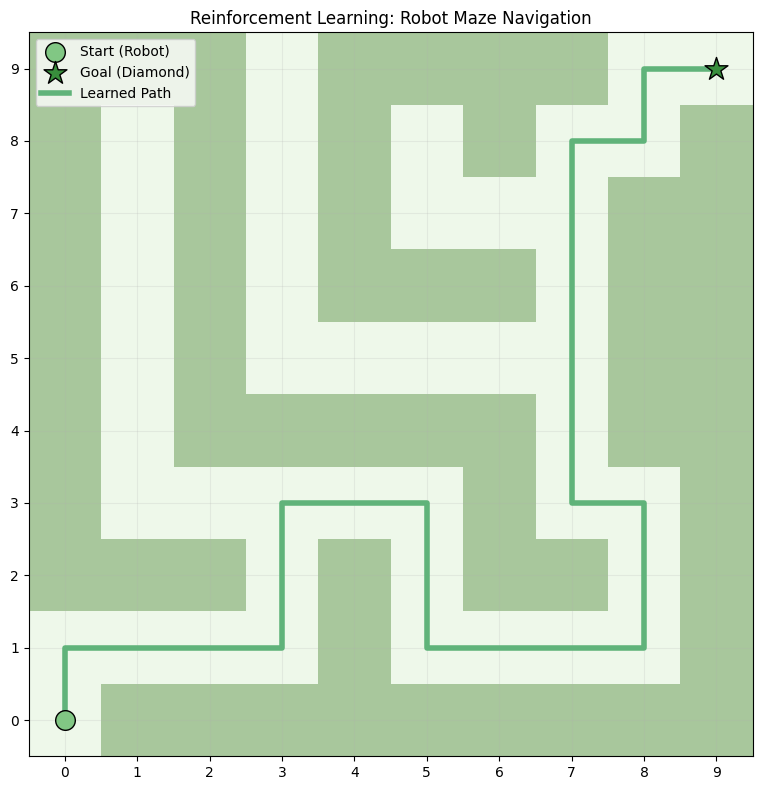

[(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (2, 8), (3, 8), (3, 7), (4, 7), (5, 7), (6, 7), (7, 7), (8, 7), (8, 8), (9, 8), (9, 9)]


In [6]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
              label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


optimal_path = get_optimal_path(Q, start, goal, actions, maze)
plot_maze_with_path(optimal_path)
print(optimal_path)